In [1]:
import h5py
import numpy as np
from scipy.io import loadmat
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from joblib import Parallel, delayed
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from statsmodels.stats.multitest import fdrcorrection
from collections import Counter

C:\Users\Danila\anaconda3\envs\monkey\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [10]:
def downsample_mean(X, factor):
    n_trials, time_len, n_channels, n_sources = X.shape
    cut_len = (time_len // factor) * factor
    X = X[:, :cut_len, :, :]
    print(X.shape)
    X = X.reshape(n_trials, cut_len // factor, factor, n_channels, n_sources)
    print(X.shape)
    return X.mean(axis=2) 
      
def balance_classes_with_sessions(X, y, sessions, random_state=42):
    X_out, y_out, s_out = [], [], []

    rng = np.random.default_rng(random_state)

    for s in np.unique(sessions):

        mask = sessions == s
        X_s = X[mask]
        y_s = y[mask]
        class_counts = Counter(y_s)
        min_count = min(class_counts.values())

        balanced_indices = []

        for cls in np.unique(y_s):
            cls_indices = np.where(y_s == cls)[0]
            selected = rng.choice(cls_indices, size=min_count, replace=False)
            balanced_indices.append(selected)

        balanced_indices = np.concatenate(balanced_indices)
        balanced_indices = np.sort(balanced_indices)

        X_out.append(X_s[balanced_indices])
        y_out.append(y_s[balanced_indices])
        s_out.append(np.full(len(balanced_indices), s))

    return (
        np.concatenate(X_out, axis=0),
        np.concatenate(y_out, axis=0),
        np.concatenate(s_out, axis=0)
    )

def extract_selected_indices(
    X,
    MUA,
    y,
    sessions,
    groups,
    position_indices,
    selected_within_group,
    condition_label,
    t_min=-0.2,
    t_max=0.6,
    baseline_window=(-0.2, -0.05),
    downsample_factor=None,
):
    """
    Parameters
    ----------
    X : array, shape (N, T, C, F)
    MUA : array, shape (N, T, C, F)
    y : array, shape (N,)
    sessions : array, shape (N,)
    groups : list of lists
    position_indices : list of ints
    selected_within_group : list of ints
    condition_label : int
    t_min, t_max : float
        Epoch time limits (seconds)
    baseline_window : tuple (start, end)
        Baseline interval in seconds
    downsample_factor : int or None
    """

    subset_label_map = {}

    for pos_label, pos_idx in enumerate(position_indices):
        group = groups[pos_idx]
        selected_labels = [
            group[i] for i in selected_within_group
            if i < len(group)
        ]
        for label in selected_labels:
            subset_label_map[label] = pos_label


    mask = np.isin(y, list(subset_label_map.keys()))

    X_subset = X[mask]
    MUA_subset = MUA[mask]
    y_subset = y[mask]
    session_subset = sessions[mask]

    y_local = np.array([subset_label_map[int(label)] for label in y_subset])
    y_condition = np.full(len(y_local), condition_label)
    MUA_subset = MUA_subset[:, :, :, 3:4]

    # Baseline correction for MUA
    N, T, C, F = MUA_subset.shape

    fs = T / (t_max - t_min)

    b_start, b_end = baseline_window
    b_start_idx = int((b_start - t_min) * fs)
    b_end_idx = int((b_end - t_min) * fs)

    if b_start_idx < 0 or b_end_idx > T:
        raise ValueError("Baseline window outside epoch range")

    baseline = MUA_subset[:, b_start_idx:b_end_idx].mean(axis=1, keepdims=True)
    MUA_subset = MUA_subset - baseline

    #Combine features
    
    X_combined = np.concatenate([X_subset, MUA_subset], axis=-1)

    if downsample_factor is not None:
        X_combined = downsample_mean(X_combined, downsample_factor)

    return X_combined, y_local, y_condition, session_subset
    
    
def compute_r2_loso(X, Y, sessions, alpha=1.0, permute=False, rng=None):
    """
    X        : (N, C) predictiors trials * channels
    Y        : (N, n_targets) trials * shapes
    sessions : (N,) session identifiers for LOSO
    alpha    : for ridge regularization
    permute  : if need to be permuted for p-value 
    """
    
    if Y.ndim == 1:
        Y = Y[:, None]
        
    unique_sessions = np.unique(sessions)
    r2_scores = np.zeros((len(unique_sessions), Y.shape[1]))

    for fold_idx, test_session in enumerate(unique_sessions):

        test_mask = sessions == test_session
        train_mask = ~test_mask

        X_tr, X_te = X[train_mask], X[test_mask]
        Y_tr, Y_te = Y[train_mask], Y[test_mask]

        # --- permutation only on train ---
        if permute:
            perm_idx = rng.permutation(len(Y_tr))
            Y_tr = Y_tr[perm_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        model = Ridge(alpha=alpha)
        model.fit(X_tr, Y_tr)
        Y_pred = model.predict(X_te)

        for k in range(Y.shape[1]):
            r2_scores[fold_idx, k] = r2_score(Y_te[:, k], Y_pred[:, k])

    return r2_scores.mean(axis=0)


def single_permutation(seed, X_f, Y, sessions, alpha):
    rng = np.random.default_rng(seed)
    return compute_r2_loso(
        X_f, Y, sessions,
        alpha=alpha,
        permute=True,
        rng=rng
    )

def create_mixed_datasets(
    X_02, y_02, sess_02,
    X_13, y_13, sess_13,
    center_positions,
    random_state=42
):
   
    mask_02_center = np.isin(y_02, center_positions)
    mask_13_center = np.isin(y_13, center_positions)

    X_02_nc, y_02_nc, s_02_nc = X_02[~mask_02_center], y_02[~mask_02_center], sess_02[~mask_02_center]
    X_02_c,  y_02_c,  s_02_c  = X_02[mask_02_center],  y_02[mask_02_center],  sess_02[mask_02_center]

    X_13_nc, y_13_nc, s_13_nc = X_13[~mask_13_center], y_13[~mask_13_center], sess_13[~mask_13_center]
    X_13_c,  y_13_c,  s_13_c  = X_13[mask_13_center],  y_13[mask_13_center],  sess_13[mask_13_center]

    # Mix A: 13_no_center + 02_center
    X_mix_A = np.concatenate([X_13_nc, X_02_c], axis=0)
    y_mix_A = np.concatenate([y_13_nc, y_02_c], axis=0)
    s_mix_A = np.concatenate([s_13_nc, s_02_c], axis=0)

    # Mix B: 02_no_center + 13_center
    X_mix_B = np.concatenate([X_02_nc, X_13_c], axis=0)
    y_mix_B = np.concatenate([y_02_nc, y_13_c], axis=0)
    s_mix_B = np.concatenate([s_02_nc, s_13_c], axis=0)

   
    X_A_bal, y_A_bal, s_A_bal = balance_classes_with_sessions(
        X_mix_A, y_mix_A, s_mix_A, random_state=random_state
    )

    X_B_bal, y_B_bal, s_B_bal = balance_classes_with_sessions(
        X_mix_B, y_mix_B, s_mix_B, random_state=random_state
    )

    return {

        "mix_A_balanced": (X_A_bal, y_A_bal, s_A_bal),
        "mix_B_balanced": (X_B_bal, y_B_bal, s_B_bal),
    }
    
def build_targets(y_labels, distances, sigma_side=0.7, beta=0.02):

    y_distance = distances[y_labels - 1]

    # W
    y_W = (
        -np.exp(-((y_distance + 2)**2) / (2 * sigma_side**2))
        -np.exp(-((y_distance - 2)**2) / (2 * sigma_side**2))
        + beta * (y_distance ** 2)
    )
    y_W = (y_W - y_W.mean()) / y_W.std()

    # U
    y_d2 = y_distance**2
    y_d2 = (y_d2 - y_d2.mean()) / y_d2.std()

    return np.column_stack([y_W, y_d2])


def sliding_window_loso(
    X,
    y_labels,
    sessions,
    distances,
    window_centers,
    window_size_sec,
    fs_down,
    alpha=1.0,
):
    """
        r2_W  (n_windows, F)
        r2_d2 (n_windows, F)
    """

    # --- Targets ---
    Y = build_targets(y_labels, distances)

    # --- Rearrange to (N, F, C, T) ---
    X = X.transpose(0, 3, 2, 1)

    N, F, C, T = X.shape
    n_windows = len(window_centers)

    r2_W = np.zeros((n_windows, F))
    r2_d2 = np.zeros((n_windows, F))

    for win_idx, center_time in enumerate(window_centers):

        start_time = center_time - window_size_sec / 2
        end_time   = center_time + window_size_sec / 2

        start_idx  = int((start_time + 0.2) * fs_down)
        end_idx    = int((end_time + 0.2) * fs_down)

        if start_idx < 0 or end_idx > T:
            continue

        X_window = X[:, :, :, start_idx:end_idx]
        X_window_mean = X_window.mean(axis=-1)  # (N, F, C)

        for f in range(F):
            X_f = X_window_mean[:, f, :]
            r2_vals = compute_r2_loso(
                X_f,
                Y,
                sessions,
                alpha=alpha
            )

            r2_W[win_idx, f]  = r2_vals[0]
            r2_d2[win_idx, f] = r2_vals[1]

    return r2_W, r2_d2


def run_sliding_loso_with_permutation(
    X_raw,
    y_labels,
    sessions,
    target_builder,
    window_centers,
    window_size_sec,
    fs_down,
    alpha=1.0,
    n_permutations=100,
    n_jobs=1,
    target_kwargs=None
):
    """
    X_raw: (N, T, C, F)
    Возвращает:
        r2_real (n_windows, F, n_targets)
        r2_perm (n_windows, F, n_targets, n_permutations)
    """

    if target_kwargs is None:
        target_kwargs = {}

    # -------- Targets --------
    Y = target_builder(y_labels, **target_kwargs)
    n_targets = Y.shape[1]

    # -------- Reshape --------
    X = X_raw.transpose(0, 3, 2, 1)  # (N, F, C, T)
    N, F, C, T = X.shape
    n_windows = len(window_centers)

    r2_real = np.zeros((n_windows, F, n_targets))
    r2_perm = np.zeros((n_windows, F, n_targets, n_permutations))

    for win_idx, center_time in enumerate(window_centers):

        start_time = center_time - window_size_sec / 2
        end_time   = center_time + window_size_sec / 2

        start_idx  = int((start_time + 0.2) * fs_down)
        end_idx    = int((end_time + 0.2) * fs_down)

        if start_idx < 0 or end_idx > T:
            continue

        # (N, F, C)
        X_window = X[:, :, :, start_idx:end_idx].mean(axis=-1)

        for f in range(F):

            X_f = X_window[:, f, :]

            # -------- REAL --------
            r2_real[win_idx, f] = compute_r2_loso(
                X_f, Y, sessions,
                alpha=alpha,
                permute=False
            )

            # -------- PERMUTATION --------
            perm_scores = Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(single_permutation)(
                    seed, X_f, Y, sessions, alpha
                )
                for seed in range(n_permutations)
            )

            r2_perm[win_idx, f] = np.array(perm_scores).T

    return r2_real, r2_perm



def find_best_low_frequency(r2_mean, freqs, fmin=5, fmax=12):

    # r2_mean: (T, F)

    low_mask = (freqs >= fmin) & (freqs <= fmax)
    low_indices = np.where(low_mask)[0]

    r2_low = r2_mean[:, low_indices]  # (T, F_low)

    # ===== Вариант A: глобальный пик =====
    max_val = np.nanmax(r2_low)
    t_idx, f_local_idx = np.unravel_index(
        np.nanargmax(r2_low),
        r2_low.shape
    )
    f_idx_global = low_indices[f_local_idx]
    best_freq_peak = freqs[f_idx_global]

    # ===== Вариант B: среднее по времени =====
    mean_over_time = np.nanmean(r2_low, axis=0)
    f_local_idx_mean = np.nanargmax(mean_over_time)
    f_idx_global_mean = low_indices[f_local_idx_mean]
    best_freq_mean = freqs[f_idx_global_mean]

    return {
        "peak_freq": best_freq_peak,
        "peak_value": max_val,
        "mean_freq": best_freq_mean,
        "mean_value": mean_over_time[f_local_idx_mean]
    }

def run_loso_temporal_generalization(
    X, y, sessions,
    window_centers,
    window_size_sec,
    fs_down,
    alpha=1.0,
    permute=False,
    random_state=None,
    n_jobs=-1
):
    """
    TG совместимый с LOSO для X: (N, T, C) — одна частота, каналы не усредняем.
    
    X: (N, T, C)
    y: (N,) - таргет
    sessions: (N,) - номера сессий
    window_centers: список центров окон (train и test)
    window_size_sec: размер окна в секундах
    fs_down: частота дискретизации
    alpha: Ridge alpha
    permute: True — перемешать y_train
    n_jobs: число потоков для Parallel
    """

    unique_sessions = np.unique(sessions)
    n_windows = len(window_centers)
    r2_all_sessions = []

    rng = np.random.default_rng(random_state)

    for test_session in tqdm(unique_sessions, desc="LOSO sessions"):
        # --- маски train/test ---
        train_mask = sessions != test_session
        test_mask  = sessions == test_session

        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        if permute:
            y_train = rng.permutation(y_train)

        # --- функция одного train-time окна ---
        def compute_train_window(i, center_train):
            r2_row = np.full(n_windows, np.nan)

            # train window индексы
            start_train = int((center_train - window_size_sec / 2 + 0.2) * fs_down)
            end_train   = int((center_train + window_size_sec / 2 + 0.2) * fs_down)

            if start_train < 0 or end_train > X.shape[1]:
                return i, r2_row

            # усреднение только по времени (оставляем каналы)
            X_train_window = X_train[:, start_train:end_train, :]  # (N_train, T_window, C)
            X_train_features = X_train_window.mean(axis=1)         # (N_train, C)

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_features)

            model = Ridge(alpha=alpha)
            model.fit(X_train_scaled, y_train)

            # --- loop по test window ---
            for j, center_test in enumerate(window_centers):
                start_test = int((center_test - window_size_sec / 2 + 0.2) * fs_down)
                end_test   = int((center_test + window_size_sec / 2 + 0.2) * fs_down)
                if start_test < 0 or end_test > X.shape[1]:
                    continue

                X_test_window = X_test[:, start_test:end_test, :]  # (N_test, T_window, C)
                X_test_features = X_test_window.mean(axis=1)       # (N_test, C)

                X_test_scaled = scaler.transform(X_test_features)
                y_pred = model.predict(X_test_scaled)
                r2_row[j] = r2_score(y_test, y_pred)

            return i, r2_row

        # --- параллельное вычисление TG ---
        results = Parallel(n_jobs=n_jobs)(
            delayed(compute_train_window)(i, center)
            for i, center in enumerate(window_centers)
        )

        # --- сборка матрицы TG для текущей сессии ---
        r2_matrix = np.full((n_windows, n_windows), np.nan)
        for i, r2_row in results:
            r2_matrix[i, :] = r2_row

        r2_all_sessions.append(r2_matrix)

    # --- усреднение по сессиям ---
    r2_mean = np.nanmean(np.stack(r2_all_sessions, axis=0), axis=0)  # (train_window, test_window)
    return r2_mean, r2_all_sessions

In [4]:
data = loadmat('C:/Users/Danila/Downloads/X_and_y_all_curveBobo.mat')  #X_and_y_all_curveBobo X_and_y_all_Bobo
with h5py.File('C:/Users/Danila/monkey_current/X_all_curveBoboV1_power_ALL_FREQS_onlyTFR_baseline.mat', 'r') as f:
    print(list(f.keys()))  # ['X_all']
    X_all = f['X_all'][:] 
y_all = data['y_all'].squeeze()
Mua = data['X_all']
# Удалим NaN
mask = ~np.isnan(y_all)
#n1, n2, n3 = 1774, 1512, 1366 #M1 attention In
n1, n2, n3 = 1346, 1660, 1237
session_ids = np.concatenate([
    np.zeros(n1, dtype=int),
    np.ones(n2, dtype=int),
    np.full(n3, 2, dtype=int)
])

#print(X_all.shape)
#X_all = X_all.transpose(1, 0, 2, 3) #for baselinecorrected Josef
X_clean = X_all[mask]
y_clean = y_all[mask]
Mua = Mua[mask]
session_ids_clean = session_ids[mask]


#groups = [
#    [1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16], [17,18,19,20],
#    [21,22,23,24], [25,26,27,28], [29,30,31,32], [33,34,35,36],
#    [37,38,39,40], [41,42,43,44], [45,46,47,48], [49,50,51,52],
#    [53,54,55,56], [57,58,59,60], [61,62,63,64], [65,66,67,68],
#    [69,70,71,72], [73,74,75,76], [77,78,79,80], [81,82,83,84],
#    [85,86,87,88], [89,90,91,92]
#]

groups = [
    [1,2,47,48], [3,4,49,50], [5,6,51,52], [7,8,53,54], [9,10,55,56], 
    [11,12,57,58], [13,14,59,60], [15,16,61,62], [17,18,63,64], 
    [19,20,65,66], [21,22,67,68], [23,24,69,70], [25,26,71,72], 
    [27,28,73,74], [29,30,75,76], [31,32,77,78], [33,34,79,80], 
    [35,36,81,82], [37,38,83,84], [39,40,85,86], [41,42,87,88], 
    [43,44,89,90], [45,46,91,92]
]
downsample_factor = 2

['X_all']


In [5]:
positions = list(range(23))

X_02, y_02, y_cond_02, session_subset02 = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[0, 2],
    condition_label=0
)

X_13, y_13, y_cond_13, session_subset03 = extract_selected_indices(
    X=X_clean,
    MUA = Mua,
    y=y_clean,
    sessions = session_ids_clean,
    groups=groups,
    position_indices=positions,
    selected_within_group=[1, 3],
    condition_label=0
)

center_positions = np.arange(8, 15)

datasets = create_mixed_datasets(
    X_02, y_02, session_subset02,
    X_13, y_13, session_subset03,
    center_positions,
    random_state=42
)

X_mix_A, y_mix_A, sess_mix_A = datasets["mix_A_balanced"]
X_mix_B, y_mix_B, sess_mix_B = datasets["mix_B_balanced"]


print(
    f"Balanced: X={X_mix_A.shape}, "
    f"y={y_mix_A.shape}, "
    f"sessions={sess_mix_A.shape}"
)
# Bobo 18 channels 
distances = np.array([
    -5.4064636817277, -4.9130019973084, -4.41954031288911,
    -3.92607862846982, -3.43261694405053, -2.93915525963124,
    -2.44569357521195, -1.95223189079266, -1.45877020637337,
    -0.965308521954082, -0.471846837534792, 0.021614846884499,
     0.515076531303789,  1.00853821572308, 1.50199990014237,
     1.99546158456166,  2.48892326898095, 2.98238495340024,
     3.47584663781953,  3.96930832223882,  4.46277000665811,
     4.9562316910774,  5.44969337549669
])

Balanced: X=(1633, 610, 18, 22), y=(1633,), sessions=(1633,)


In [6]:
fs_down = 610 / 0.8  # 381.25 Hz
window_size_sec = 0.05
step_sec = 0.025
start_time_total = -0.2
end_time_total = 0.6
n_splits = 3
alpha = 1.0
n_permutations = 1000
n_jobs = -1


window_centers = []
start_time = start_time_total
while start_time + window_size_sec <= end_time_total:
    center_time = (start_time + start_time + window_size_sec) / 2
    window_centers.append(center_time)
    start_time += step_sec
n_windows = len(window_centers)

In [7]:
results = {}

for name, (X_data, y_data, sess_data) in {
    "mix_A": datasets["mix_A_balanced"],
    "mix_B": datasets["mix_B_balanced"],
}.items():

    r2_W, r2_d2 = sliding_window_loso(
        X_data,
        y_data,
        sess_data,
        distances,
        window_centers,
        window_size_sec,
        fs_down,
        alpha=alpha
    )

    results[name] = {
        "r2_W": r2_W,
        "r2_d2": r2_d2
    }

In [11]:
results = {}

for name, (X_data, y_data, sess_data) in {
    "mix_A": datasets["mix_A_balanced"],
    "mix_B": datasets["mix_B_balanced"],
}.items():

    print(f"Running decoding for {name}")

    r2_real, r2_perm = run_sliding_loso_with_permutation(
        X_raw=X_data,
        y_labels=y_data,
        sessions=sess_data,
        target_builder=build_targets,
        window_centers=window_centers,
        window_size_sec=window_size_sec,
        fs_down=fs_down,
        alpha=alpha,
        n_permutations=n_permutations,
        n_jobs=n_jobs,
        target_kwargs=dict(
            distances=distances,
            sigma_side=0.7,
            beta=0.02
        )
    )

    results[name] = {
        "r2_real": r2_real,
        "r2_perm": r2_perm
    }

print("LOSO permutation finished!")

Running decoding for mix_A
Running decoding for mix_B
LOSO permutation finished!


In [13]:
r2_real.shape

(30, 22, 2)

In [17]:

# ---------- подготовка данных для сохранения ----------
def save_r2_results(filename, r2_real, r2_perm, window_centers):
    """
    Сохраняет результаты LOSO R² в формате, аналогичном старым npz.
    """
    r2_W_flat  = r2_real[:, :, 0]  # W_flat
    r2_U_shape = r2_real[:, :, 1]  # U_shape

    r2_perm_W_flat  = r2_perm[:, :, 0]
    r2_perm_U_shape = r2_perm[:, :, 1]

    np.savez(
        filename,
        r2_W_flat=r2_W_flat,
        r2_U_shape=r2_U_shape,
        r2_perm_W_flat=r2_perm_W_flat,
        r2_perm_U_shape=r2_perm_U_shape,
        window_centers=window_centers
    )
    print(f"Saved {filename}")

# ---------- сохраняем отдельно для A и B ----------
save_r2_results("M1V1_r2_results_and_permutations02curve.npz",
                results["mix_A"]["r2_real"],
                results["mix_A"]["r2_perm"],
                window_centers)

save_r2_results("M1V1_r2_results_and_permutations13curve.npz",
                results["mix_B"]["r2_real"],
                results["mix_B"]["r2_perm"],
                window_centers)

Saved M1V1_r2_results_and_permutations02curve.npz
Saved M1V1_r2_results_and_permutations13curve.npz


In [69]:
datasets = {
    'V1': {
        '02': np.load('C:/Users/Danila/M1V1_LOSO_r2_results_and_permutations02.npz'),
        '13': np.load('C:/Users/Danila/M1V1_LOSO_r2_results_and_permutations13.npz'),
    },
    'V4': {
        '02': np.load('C:/Users/Danila/m1V4_r2_results_and_permutations02.npz'),
        '13': np.load('C:/Users/Danila/m1V4_r2_results_and_permutations13.npz'),
    }
}

In [77]:
low_freq_mask = (freqs >= 5) & (freqs <= 12)
low_freq_indices = np.where(low_freq_mask)[0]

# Получаем r2_mean для U
d02 = datasets['V1']['02']
d13 = datasets['V1']['13']
r2_mean_U = 0.5 * (d02['r2_d2'] + d13['r2_d2'])

# Получаем r2_mean для W
r2_mean_W = 0.5 * (d02['r2_W_flat'] + d13['r2_W_flat'])

best_U = find_best_low_frequency(r2_mean_U, freqs)
best_W = find_best_low_frequency(r2_mean_W, freqs)

print("U-shape best freq (peak):", best_U["peak_freq"], "Hz")
print("U-shape best freq (mean):", best_U["mean_freq"], "Hz")

print("W-shape best freq (peak):", best_W["peak_freq"], "Hz")
print("W-shape best freq (mean):", best_W["mean_freq"], "Hz")


U-shape best freq (peak): 9 Hz
U-shape best freq (mean): 9 Hz
W-shape best freq (peak): 8 Hz
W-shape best freq (mean): 9 Hz


In [ ]:
TG time-generalization 

In [92]:
results = {}

for name, (X_data, y_labels, sess_data) in {
    "mix_A": datasets["mix_A_balanced"],
    "mix_B": datasets["mix_B_balanced"],
}.items():

    # --- построим таргеты (W и U) для текущего набора ---
    Y_targets = build_targets(y_labels, distances)  # (N, 2)
    y_W_flat = Y_targets[:, 0]
    y_d2     = Y_targets[:, 1]

    # -------------------------------
    # W-shape
    # -------------------------------
    print(X_data.shape)
    X_data = X_data[:, :, :, 4]
    print(X_data.shape)
    r2_W_mean, r2_W_per_session = run_loso_temporal_generalization(
        X_data,
        y_W_flat,          # таргет W-shape
        sess_data,
        window_centers=window_centers,
        window_size_sec=window_size_sec,
        fs_down=fs_down,
        alpha=alpha,
        permute=False,
        random_state=42,
        n_jobs=-1
    )

    # -------------------------------
    # U-shape (d2)
    # -------------------------------
    r2_d2_mean, r2_d2_per_session = run_loso_temporal_generalization(
        X_data,
        y_d2,              # таргет U-shape / d2
        sess_data,
        window_centers=window_centers,
        window_size_sec=window_size_sec,
        fs_down=fs_down,
        alpha=alpha,
        permute=False,
        random_state=42,
        n_jobs=-1
    )

    # -------------------------------
    # Сохраняем
    # -------------------------------
    results[name] = {
        "r2_W_mean": r2_W_mean,
        "r2_W_per_session": r2_W_per_session,
        "r2_d2_mean": r2_d2_mean,
        "r2_d2_per_session": r2_d2_per_session
    }

print("LOSO + TG расчёты завершены для всех наборов")

(1909, 610, 18, 22)
(1909, 610, 18)


LOSO sessions: 100%|██████████| 3/3 [00:04<00:00,  1.40s/it]


(1725, 610, 18, 22)
(1725, 610, 18)


LOSO sessions: 100%|██████████| 3/3 [00:03<00:00,  1.27s/it]

LOSO + TG расчёты завершены для всех наборов


In [ ]:
n_permutations = 1000
results = {}

for name, (X_data, y_labels, sess_data) in {
    "mix_A": datasets["mix_A_balanced"],
    "mix_B": datasets["mix_B_balanced"],
}.items():

    print(f"\nProcessing {name}")

    # --- таргеты ---
    Y_targets = build_targets(y_labels, distances)
    y_W_flat = Y_targets[:, 0]
    y_d2     = Y_targets[:, 1]

    # --- выбираем одну частоту ---
    X_data = X_data[:, :, :, 4]  # (N, T, C)

    # ==================================================
    # 1️⃣ REAL DATA
    # ==================================================
    r2_W_mean, r2_W_sessions = run_loso_temporal_generalization(
        X_data, y_W_flat, sess_data,
        window_centers, window_size_sec, fs_down,
        alpha=alpha, permute=False, random_state=42
    )

    r2_d2_mean, r2_d2_sessions = run_loso_temporal_generalization(
        X_data, y_d2, sess_data,
        window_centers, window_size_sec, fs_down,
        alpha=alpha, permute=False, random_state=42
    )

    # ==================================================
    # 2️⃣ PERMUTATIONS
    # ==================================================
    print("Running permutations...")

    r2_W_perm = []
    r2_d2_perm = []

    for p in tqdm(range(n_permutations)):

        r2_W_p, _ = run_loso_temporal_generalization(
            X_data, y_W_flat, sess_data,
            window_centers, window_size_sec, fs_down,
            alpha=alpha, permute=True, random_state=p
        )

        r2_d2_p, _ = run_loso_temporal_generalization(
            X_data, y_d2, sess_data,
            window_centers, window_size_sec, fs_down,
            alpha=alpha, permute=True, random_state=p
        )

        r2_W_perm.append(r2_W_p)
        r2_d2_perm.append(r2_d2_p)

    r2_W_perm = np.stack(r2_W_perm, axis=0)    # (1000, n_win, n_win)
    r2_d2_perm = np.stack(r2_d2_perm, axis=0)

    # ==================================================
    # 3️⃣ P-VALUE
    # ==================================================
    p_W = (1 + np.sum(r2_W_perm >= r2_W_mean, axis=0)) / (1 + n_permutations)
    p_d2 = (1 + np.sum(r2_d2_perm >= r2_d2_mean, axis=0)) / (1 + n_permutations)

    # ==================================================
    # 4️⃣ SAVE
    # ==================================================
    results[name] = {
        "r2_W_mean": r2_W_mean,
        "r2_W_perm": r2_W_perm,
        "p_W": p_W,
        "r2_d2_mean": r2_d2_mean,
        "r2_d2_perm": r2_d2_perm,
        "p_d2": p_d2
    }

print("LOSO + TG + 1000 permutations finished")


In [95]:
import os
import numpy as np

save_dir = "M1V1tg_loso_results_9hz"
os.makedirs(save_dir, exist_ok=True)

for name in results.keys():

    save_path = os.path.join(save_dir, f"{name}_tg_results.npz")

    np.savez_compressed(
        save_path,
        r2_W_mean=results[name]["r2_W_mean"],
        r2_W_perm=results[name]["r2_W_perm"],
        p_W=results[name]["p_W"],
        r2_d2_mean=results[name]["r2_d2_mean"],
        r2_d2_perm=results[name]["r2_d2_perm"],
        p_d2=results[name]["p_d2"],
        window_centers=window_centers,
        window_size_sec=window_size_sec,
        fs_down=fs_down
    )

    print(f"Saved {name} → {save_path}")

print("All results saved successfully.")


Saved mix_A → M1V1tg_loso_results_9hz\mix_A_tg_results.npz
Saved mix_B → M1V1tg_loso_results_9hz\mix_B_tg_results.npz
All results saved successfully.


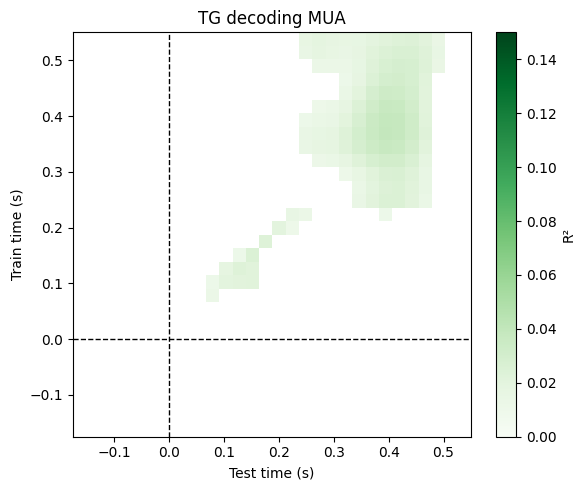

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import fdrcorrection

# ============================================
# ПАРАМЕТРЫ
# ============================================

alpha_fdr = 0.05
r2_min = 0.01

path_A = r"C:\Users\Danila\M1V1tg_loso_results_9hz\mix_A_tg_results.npz"
path_B = r"C:\Users\Danila\M1V1tg_loso_results_9hz\mix_B_tg_results.npz"

# ============================================
# ЗАГРУЗКА
# ============================================

data_A = np.load(path_A)
data_B = np.load(path_B)

r2_A = data_A["r2_d2_mean"]        # (T_train, T_test)
r2_B = data_B["r2_d2_mean"]

perm_A = data_A["r2_d2_perm"]      # (T_train, T_test, P)
perm_B = data_B["r2_d2_perm"]

window_centers = data_A["window_centers"]

# ============================================
# 1) Усредняем реальные R²
# ============================================

r2_mean = 0.5 * (r2_A + r2_B)

# ============================================
# 2) Усредняем пермутации
# ============================================

perm_mean = 0.5 * (perm_A + perm_B)

# ============================================
# 3) Считаем p-value
# ============================================


# perm сейчас (P, T, T) → делаем (T, T, P)
perm_mean = np.transpose(perm_mean, (1, 2, 0))

n_perm = perm_mean.shape[-1]

# p = доля perm >= real
p_vals = np.mean(perm_mean >= r2_mean[..., None], axis=-1)

p_flat = p_vals.ravel()
reject, p_fdr = fdrcorrection(p_flat, alpha=alpha_fdr)
sig_mask = reject.reshape(p_vals.shape)

# дополнительный порог по r2
sig_mask &= (r2_mean >= r2_min)

# ============================================
# 5) Маскируем незначимые
# ============================================

r2_plot = r2_mean.copy()
r2_plot[~sig_mask] = np.nan

# ============================================
# 6) PLOT TG
# ============================================

fig, ax = plt.subplots(figsize=(6, 5))

cmap = plt.get_cmap("Greens").copy()
cmap.set_bad("white")

im = ax.imshow(
    r2_plot,
    origin="lower",
    aspect="auto",
    extent=[
        window_centers[0],
        window_centers[-1],
        window_centers[0],
        window_centers[-1],
    ],
    vmin=0,
    vmax=0.15,
    cmap=cmap,
)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Test time (s)")
ax.set_ylabel("Train time (s)")
ax.set_title("TG decoding MUA")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("R²")

plt.tight_layout()
#fig.savefig("V1_TG_r2_d2_mean_AB.png", dpi=600, bbox_inches="tight")
plt.show()